## rSVD Projected Tikhonov Solution
The purpose of this notebook is to find a good $\nu_{dp}$ for use in the discrepancy principle for automatically choosing $\lambda$ in a noisy projected Tikhonov problem:

I consider the problem of determining $\lambda$ for
$$
\min_x \| K^+ K x - K^+ \tilde y \|_{M_\partial}^2 + \lambda^2 \| W x \|_M^2
$$
where
$$
\tilde y = y + \epsilon,\quad
y = K x,\quad
\frac{\| \epsilon \|}{\|y \|} = \delta
$$
using the discrepancy principle. I choose $\lambda$ such that
$$
\| K x_\lambda - \tilde y \| \approx \nu_{dp} \| \epsilon \|
$$
Based on the plots, the best $\nu_{dp}$ to use are:
 - $\nu_{dp} = 5$ (test problem I) 
 - $\nu_{dp} = 3$ (test problem II) 
 - $\nu_{dp} = 10$ (test problem III) 

An overall value of $\nu_{dp}=5$ works well for all. I will use value in my thesis.

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from typing import Optional
from fenics import Function, plot
from utils.solvers import fast_proj_solver
from utils.problem_setup import TestProblemsSetup
from algorithms.matrix_free_rsvd import get_approximate_W

SEED = 15

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
setup = TestProblemsSetup(n=64)
problems = setup.get_test_problems()
problem_params = setup.problem_params

In [3]:
def discrepancy_principle(x, y, U, S, V, M, w, norm_epsilon, nu=2.0):
    # Track
    num = 25
    lambdas = np.logspace(-4, 1, num)
    residuals = np.zeros(num)
    errors = np.zeros(num)

    for i, lam in enumerate(lambdas):
        x_lam = fast_proj_solver(U, S, V, M, w, y, lambda_=lam)
        Kx_lam = U @ (S * (V.T @ x_lam))

        residuals[i] = np.linalg.norm(Kx_lam - y)
        errors[i] = np.linalg.norm(x_lam - x)

    # Compute optimal lambda based on DP and error
    idx_dp = np.where(residuals > nu * norm_epsilon)[0][0]
    idx_opt = np.argmin(errors)
    lam_dp = lambdas[idx_dp]
    lam_opt = lambdas[idx_opt]
    e_dp = residuals[idx_dp]
    e_opt = residuals[idx_opt]
    return lam_dp, lam_opt, e_dp, e_opt, lambdas, residuals, errors


def plot_dp(lam_dp, lam_opt, lambdas, residuals, errors, norm_epsilon, nu):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))

    ax1.loglog(lambdas, residuals, '-o')
    ax1.axhline(norm_epsilon, c='r', ls='--',
                label=f'$\| \epsilon \|$={norm_epsilon:.3f}')
    ax1.axhline(nu * norm_epsilon, c='orange', ls='--',
                label=f'$\\nu_{{dp}}\| \epsilon \|$={nu * norm_epsilon:.3f}')
    ax1.axvline(lam_dp, c='g', ls='--', label=f'$\lambda_{{dp}}$={lam_dp:.2f}')

    ax2.loglog(lambdas, errors, '-o')
    ax2.axvline(lam_opt, c='g', ls='--', label=f'$\lambda^*$={lam_opt:.2f}')

    ax1.set_xlabel('$\lambda$', fontsize=13)
    ax1.set_title('$\| K x_\lambda - \\tilde y \|$', fontsize=13)
    ax2.set_xlabel('$\lambda$', fontsize=13)
    ax2.set_title('$\| x_\lambda - x \|$', fontsize=13)

    ax2.grid(True, alpha=0.5, which='both')
    ax1.grid(True, alpha=0.5, which='both')
    ax2.legend()
    ax1.legend()

    plt.tight_layout()
    plt.show()


def plot_solutions(f_list, params, titles):
    from utils.colors import CMAP
    import matplotlib.patches as patches
    width = params['width']
    height = params['height']
    x0s, y0s = params['x0'], params['y0']

    fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
    axes = axes.flatten()

    for ax, fi, ti in zip(axes, f_list, titles):
        plt.sca(ax)
        p = plot(fi, cmap=CMAP) #, norm=norm)

        ax.set_title(ti)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(p, ax=ax, format="%.2f", shrink=0.655)

        for x0, y0 in zip(x0s, y0s):
            square = patches.Rectangle((x0, y0), width, height,
                edgecolor="white",facecolor="none")
            ax.add_patch(square)
    plt.show()


def plot_dp_and_opt_solution(pb, U, S, V, M, w, y_tilde, lam_dp, lam_opt, pid):
    f_list = []
    titles = []
    e = []
    for lam in [lam_dp, lam_opt]:
        f_hat = Function(pb['V_h'])
        x_hat = fast_proj_solver(U, S, V, M, w, y_tilde, lam)  
        f_hat.vector()[:] = x_hat
        f_list.append(f_hat)
        e.append(np.linalg.norm(x_hat - pb['x']))
        
    titles = [f'$\lambda_{{dp}}$={lam_dp:.2}, $e$={e[0]:.1f}',
            f'$\lambda^*$={lam_opt:.2}, $e$={e[1]:.1f}']

    plot_solutions(f_list, problem_params[pid], titles)


In [4]:
def get_epsilon(y: np.ndarray, relative: float, seed: Optional[int] = None):
    rng = np.random.default_rng(seed)
    epsilon = rng.standard_normal(y.shape)
    epsilon /= np.linalg.norm(epsilon)
    return epsilon * relative * np.linalg.norm(y)


In [5]:
def plot_dp_at_k(k, nu, pid):
    pb = problems[pid]
    rsvd = pb['rsvd']
    y = pb['y']
    x = pb['x']

    delta = 0.01
    epsilon = get_epsilon(y, delta, seed=SEED)
    y_tilde = y + epsilon

    U, S, Vt = rsvd.mf_rsvd(k=k)
    w = get_approximate_W(Vt.T, rsvd.M_dx)
    norm_epsilon = np.linalg.norm(epsilon)
    lam_dp, lam_opt, e_dp, e_opt, lambdas, residuals, errors = discrepancy_principle(
        x, y_tilde, U, S, Vt.T, rsvd.M_dx, w, norm_epsilon, nu=nu
    )
    plot_dp(lam_dp, lam_opt, lambdas, residuals, errors, norm_epsilon, nu)
    plot_dp_and_opt_solution(
        pb, U, S, Vt.T, rsvd.M_dx, w, y_tilde, lam_dp, lam_opt, pid
    )

---
### Test problem I

Based on the plots below, $\nu_{dp}=5$ works well for test problem I.

#########################  k = 20  #########################


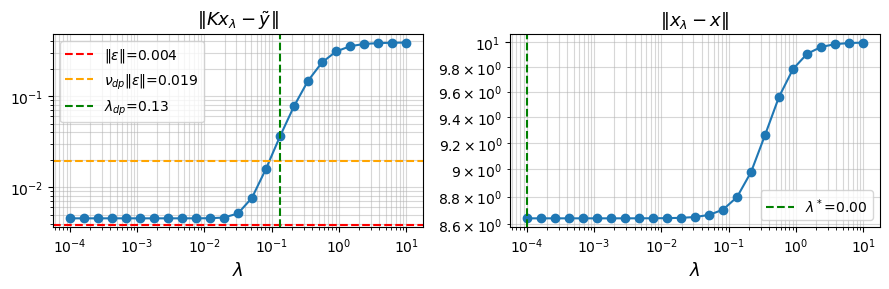

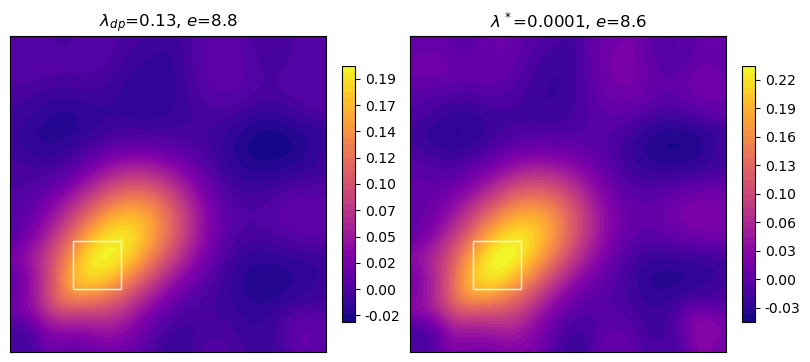

#########################  k = 50  #########################


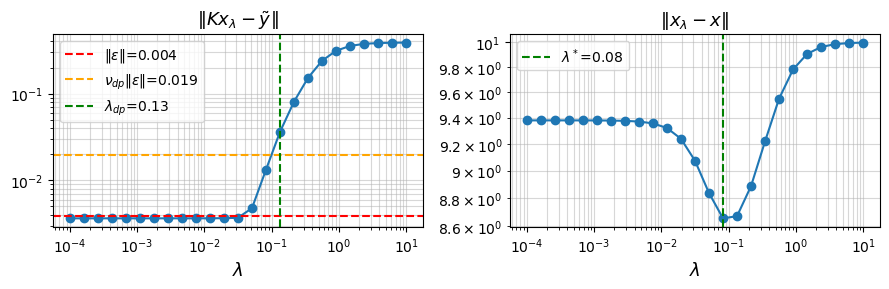

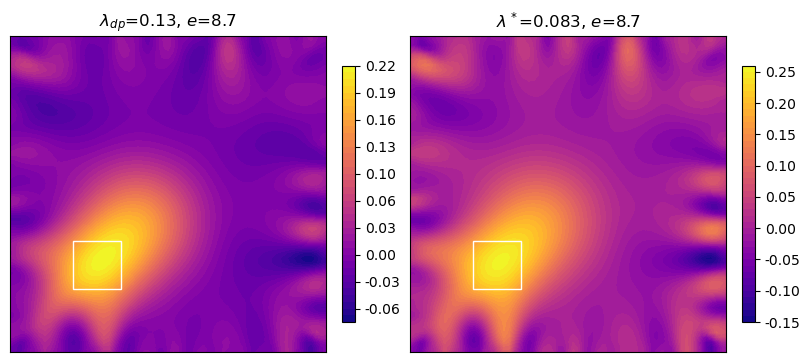

#########################  k = 100  #########################


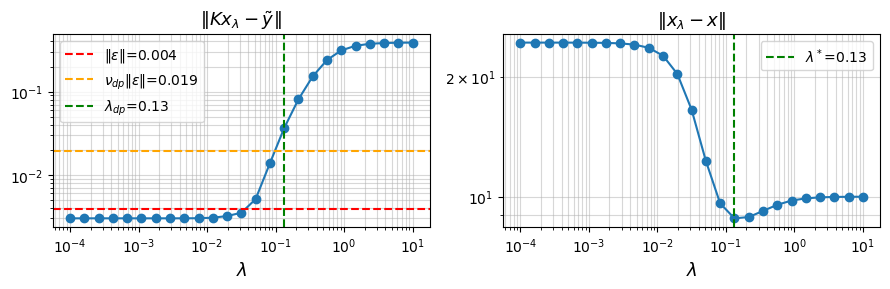

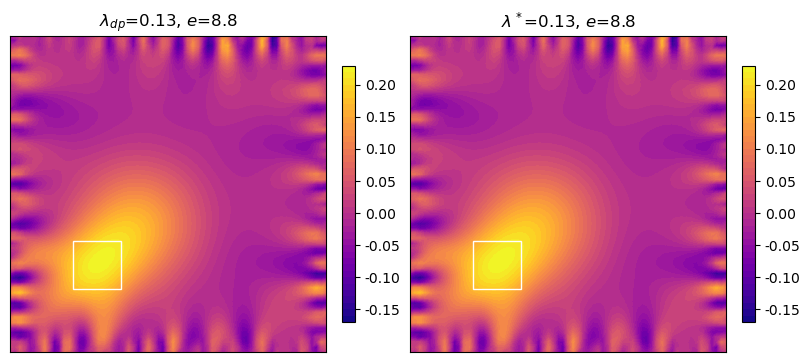

In [6]:
pid = 'I'
nu = 5
for k in [20, 50, 100]:
    print('#'*25 + f'  k = {k}  ' + '#'*25)
    plot_dp_at_k(k=k, nu=nu, pid=pid)

---
### Test problem II


#########################  k = 20  #########################


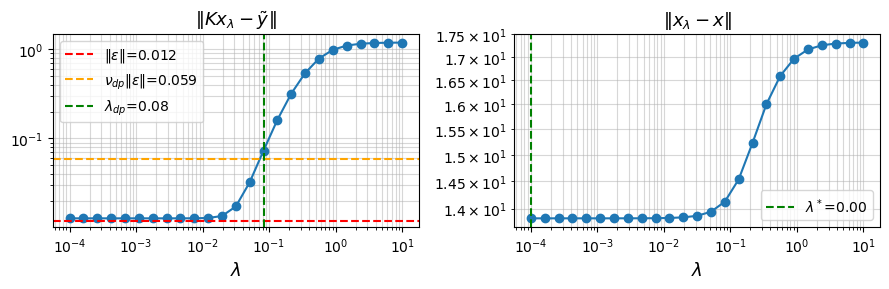

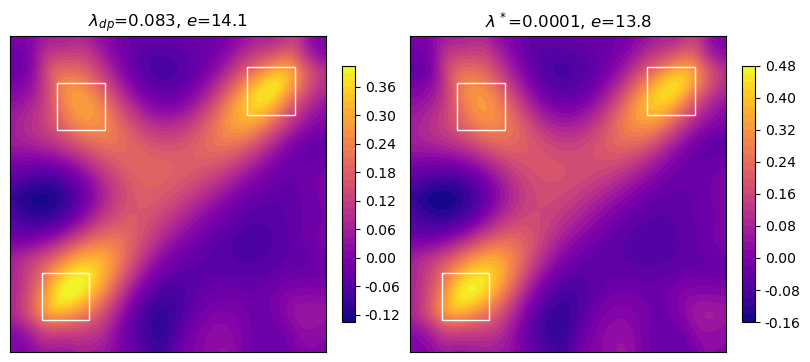

#########################  k = 50  #########################


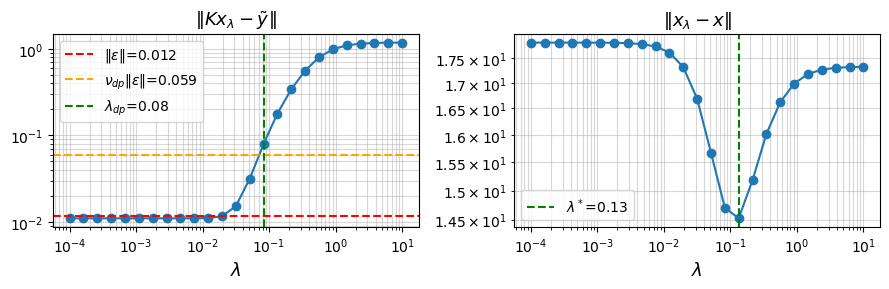

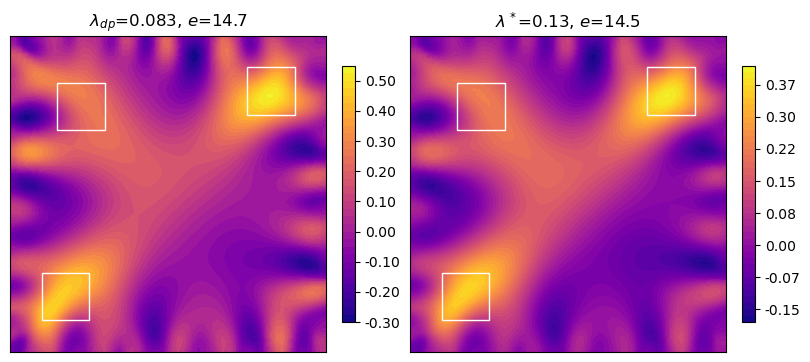

#########################  k = 100  #########################


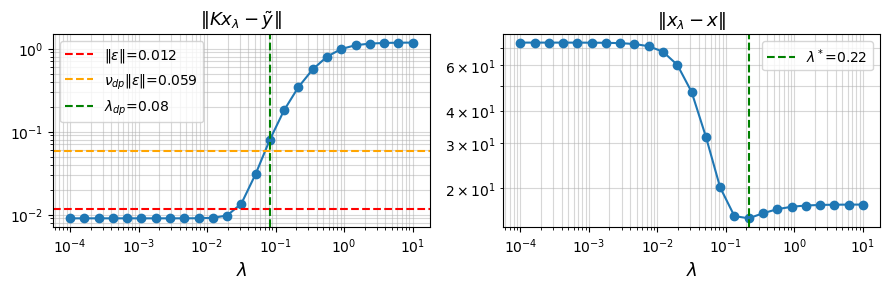

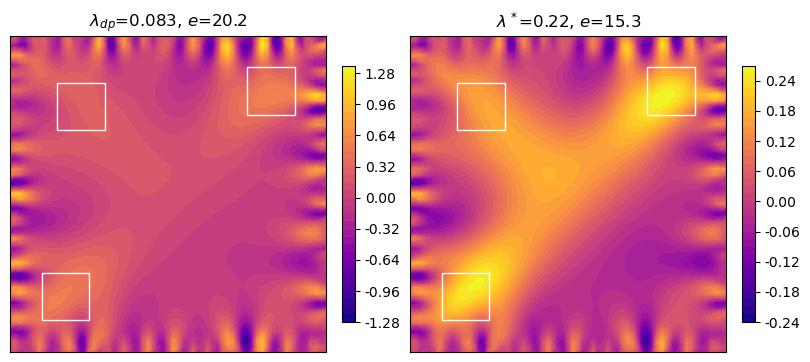

In [7]:
pid = 'II'
nu = 5
for k in [20, 50, 100]:
    print('#'*25 + f'  k = {k}  ' + '#'*25)
    plot_dp_at_k(k=k, nu=nu, pid=pid)

### Test problem III

---

#########################  k = 20  #########################


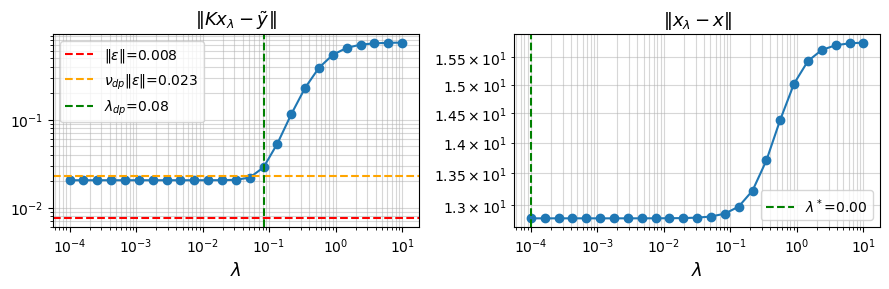

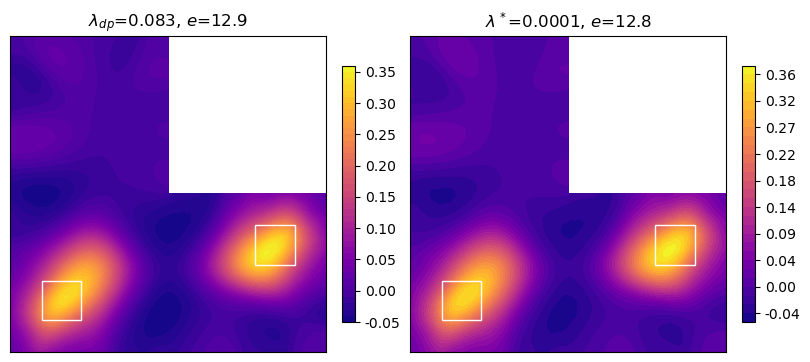

#########################  k = 50  #########################


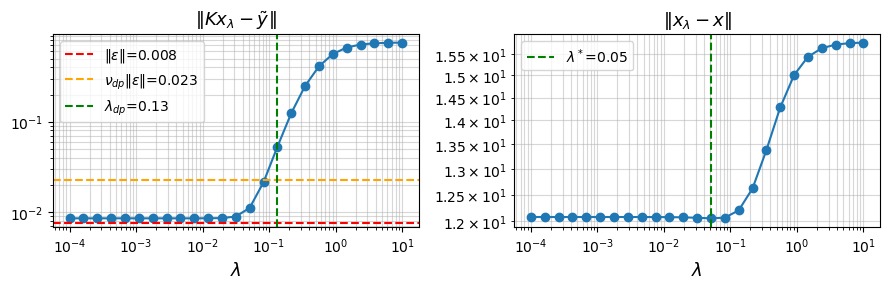

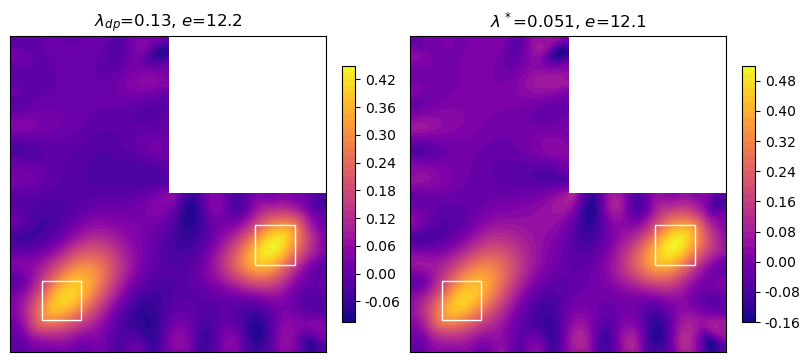

#########################  k = 100  #########################


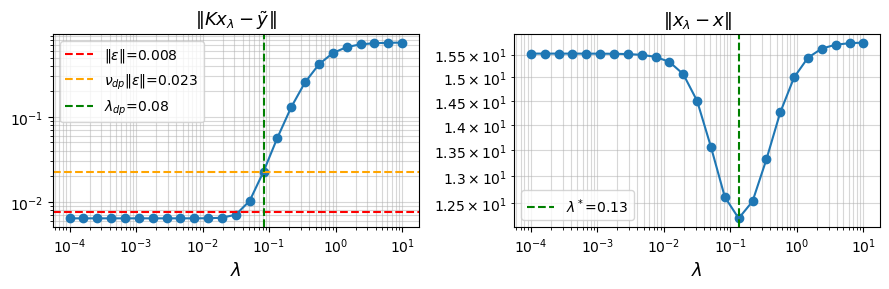

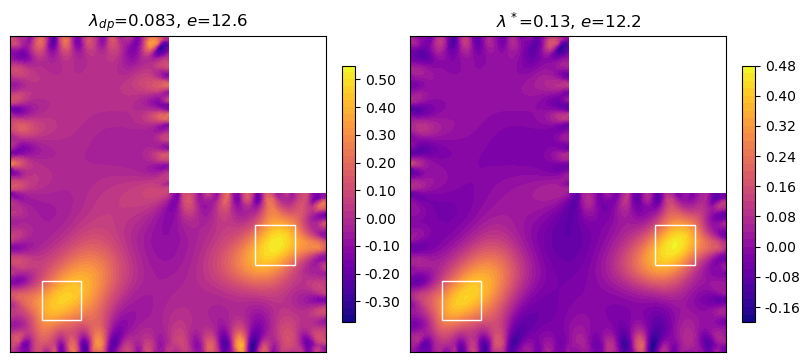

In [8]:
pid = 'III'
nu = 3
for k in [20, 50, 100]:
    print('#'*25 + f'  k = {k}  ' + '#'*25)
    plot_dp_at_k(k=k, nu=nu, pid=pid)